<a href="https://colab.research.google.com/github/ChristineHarvey/InformationLossScore/blob/main/4multiclinsum_prototype_bioembeddings2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


MULTICLINSUM INFORMATION LOSS ANALYSIS SCORE


End-to-end NLP pipeline for measuring information loss between Full Clinical Reports and their associated Clinical Summaries, using the MultiClinSum v8 dataset.


PIPELINE


1. Installation and imports
2. Load models
3. Data ingestion and preprocessing
4. Clinical NER extraction
5. Embedding generation
6. Metric computation and Final Information Loss Score
7. Analysis
8. Visualisation
9. Save results


EXPECTED DATASET STRUCTURE


project_folder/

    multiclinsum_large-scale_train_en/
        fulltext/
            multiclinsum_ls_en_1.txt
            ...
        summaries/
            multiclinsum_ls_en_1_sum.txt
            ...

    multiclinsum_gs_train_en/
        fulltext/
        summaries/

    multiclinsum_test_en/
        fulltext/
        summaries/

In [9]:
#====================================================================
# 1 - INSTALLATION
#====================================================================
!pip install transformers==4.30.0

!pip install pandas numpy matplotlib scikit-learn scipy
!pip install transformers sentence-transformers
!pip install spacy rouge-score bert-score
!pip install stanza

# ==================================================================
# 1 - IMPORTS
# ==================================================================

import os
import glob
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### models ####
import spacy  #for NLP
import stanza  #alt for NLP
from sentence_transformers import SentenceTransformer  #for embedding generation

#### metrics ####
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer  #from spacy
from bert_score import score as bertscore  #from spacy
from sklearn.feature_extraction.text import CountVectorizer  #in JS-divergence
from scipy.spatial.distance import jensenshannon
from collections import Counter #in Entropy Loss
from scipy.stats import entropy
#or from sklearn.metrics import normalized_mutual_info_score


  Using cached transformers-4.30.0-py3-none-any.whl.metadata (113 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.13.3.tar.gz (314 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached transformers-4.30.0-py3-none-any.whl (7.2 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


In [19]:
# ==================================================================
# 2 - LOAD MODELS
# ==================================================================

print("Loading models...")

# creating nlp model from spacy using pre-trained pipeline for English
nlp = spacy.load("en_core_web_sm")
#!python -m spacy download en_core_web_sm
#print(nlp.get_pipe("ner").labels)

#alternatively used STANZA to create nlp model
nlp_stanza = stanza.Pipeline('en', processors='tokenize,ner')

# creating baseline embedding model from SentenceTransformer
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# creating Biomedical embeddings from the PubMedBERT-base-embeddings model fined-tuned using sentence-transformers
embedding_biomed = SentenceTransformer("neuml/biomedbert-base-embeddings")
#embedding_biomed = SentenceTransformer("sentence-transformers/BiomedNLP/PubMedBERT-base-uncased-abstract-fulltext")

print("Models loaded")


Loading models...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.96k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/706k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

Models loaded


In [54]:
# #mount folder
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

#start with MultiClinSum/multiclinsum_gs_train_en/ as prototype
!cp -r "/content/drive/MyDrive/MultiClinSum/multiclinsum_gs_train_en/" /content/
print("drive connected to colab")

# ==================================================================
# 3 - DATA INGESTION
# ==================================================================

def load_multiclinsum_dataset(base_folder, dataset_name):
    """
    Loads report-summary pairs from MultiClinSum
    """
    fulltext_folder = os.path.join(base_folder, "fulltext")
    summary_folder = os.path.join(base_folder, "summaries")

    data = []

    report_files = glob.glob(os.path.join(fulltext_folder, "*.txt"))

    print(f"Loading dataset: {dataset_name}")
    print(f"Found {len(report_files)} reports")

    for report_path in report_files:
        report_filename = os.path.basename(report_path)
        # remove .txt
        report_id = report_filename.replace(".txt", "")
        # create matching summary filename
        summary_filename = f"{report_id}_sum.txt"
        summary_path = os.path.join(summary_folder, summary_filename)

        # skip if missing summary
        if not os.path.exists(summary_path):
            print(f"WARNING: Missing summary -> {report_id}")
            continue

        # read report
        with open(report_path, "r", encoding="utf-8") as f:
            report_text = f.read()

        # read summary
        with open(summary_path, "r", encoding="utf-8") as f:
            summary_text = f.read()

        data.append({
            "dataset": dataset_name,
            "report_id": report_id,
            "report_text": report_text,
            "summary_text": summary_text
        })
    return pd.DataFrame(data)

DATASET_FOLDERS = {
  "gold_standard": "/content/multiclinsum_gs_train_en" #,
  #"large_scale": "multiclinsum_large-scale_train_en",
  #"test": "/content/MultiClinSum/multiclinsum_test_en"
}
all_dfs = []

for dataset_name, folder_path in DATASET_FOLDERS.items():
    if os.path.exists(folder_path):
        dataset_df = load_multiclinsum_dataset(folder_path, dataset_name)
        all_dfs.append(dataset_df)
    else:
        print(f"WARNING: Folder not found -> {folder_path}")

# combine
df = pd.concat(all_dfs, ignore_index=True)

print("Total samples:", len(df))
print("Dataset counts:")
print(df["dataset"].value_counts())


# ==================================================================
# 3 - DATA PREPROCESSING
# ==================================================================

def preprocess_text(text):
    """
    Basic preprocessing
    """
    text = str(text)
    # lowercase
    text = text.lower()
    # remove extra spaces
    text = re.sub(r"\s+", " ", text)
    # remove special characters
    #text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    return text.strip()

print("Preprocessing text")

df["report_clean"] = df["report_text"].apply(preprocess_text)
df["summary_clean"] = df["summary_text"].apply(preprocess_text )

def remove_duplicate_sentences(text):
    sentences = text.strip().split(". ")
    # or sentences = re.split(r'\. ', text.strip())
    return ". ".join(dict.fromkeys(sentences))

df["report_deduplicated"] = df["report_clean"].apply(remove_duplicate_sentences)
df["summary_deduplicated"] = df["summary_clean"].apply(remove_duplicate_sentences)

# Find texts that were changed
changed = df[
    (df["report_clean"] != df["report_deduplicated"]) |
    (df["summary_clean"] != df["summary_deduplicated"])
    ]

#visual check of changed text
for _, row in changed.iterrows():
    print("\n" + "=" * 100)
    print("REPORT ID:", row["report_id"])
    print("=" * 100)

    print("\nORIGINAL:")
    print(row["report_clean"])

    print("\nCHANGED:")
    print(row["report_deduplicated"])

print("Preprocessing complete")

# Select columns to export
changed_export = changed[
    [   "report_id",
        "report_clean",
        "report_deduplicated",
        "summary_clean",
        "summary_deduplicated"
    ]
]

# Save to CSV
changed_export.to_csv("changed_reports.csv", index=False)

Mounted at /content/drive/
drive connected to colab
Loading dataset: gold_standard
Found 592 reports
Total samples: 592
Dataset counts:
dataset
gold_standard    592
Name: count, dtype: int64
Preprocessing text

REPORT ID: multiclinsum_gs_en_548

ORIGINAL:
25-year-old female patient admitted to the central emergency room of the institution with a history of abdominal cramp-like pain of 48 hours duration, of high intensity, of sudden onset, following a large intake of cooked corn, located in the right half of the abdomen, not irradiated, associated with repeated episodes of nausea and vomiting of the alimentary type. the patient reported a history of abdominal pain of similar characteristics but of lower intensity during the 4 weeks prior to the consultation, which partially subsided with diet, gastroprotective medication and oral anti-spasmodics. she reported a positive catharsis 24 hours prior to the consultation and no elimination of gases in the last 12 hours. the patient had a histo

In [5]:
# ==================================================================
# 4 - BASIC CLINICAL NER EXTRACTION
# ==================================================================

#https://spacy.io/api/doc#ents


def extract_entities(text):
    """
    Extract named entities using spacy doc.ents property
    """
    doc = nlp(text)

    #store entities
    entities = []
    for ent in doc.ents:
        entities.append((ent.text, ent.label_))
    return list(set(entities))

print("Extracting entities")

df_NER = df[["report_clean","summary_clean"]].copy()
df_NER["report_entities"] = df_NER["report_clean"].apply(extract_entities)
df_NER["summary_entities"] = df_NER["summary_clean"].apply(extract_entities)

print("NER extraction complete")

print("================================================")
print("NER OVERVIEW")
print("================================================")

print(df_NER[["report_entities", "summary_entities"]].head())

print("================================================")
print("NER VISUALISATION")
print("================================================")

# from spacy import displacy
# displacy.render(doc, style='ent', jupyter=True)

#output entities to compare
OUTPUT_FILE = "entities.csv"
df_NER.to_csv(OUTPUT_FILE, index=False)
print("RESULTS SAVED as", OUTPUT_FILE)


Extracting entities
NER extraction complete
NER OVERVIEW
                                     report_entities  \
0  [(243, CARDINAL), (3.1%, PERCENT), (day seven,...   
1  [(400, CARDINAL), (a few months, DATE), (232 p...   
2  [(4 months, DATE), (every 2 weeks, DATE), (500...   
3  [(0.6, CARDINAL), (95th, ORDINAL), (four weeks...   
4  [(three days later, DATE), (180, CARDINAL), (0...   

                                    summary_entities  
0  [(the third day, DATE), (26-year-old, DATE), (...  
1  [(iranian, NORP), (150, CARDINAL), (40-year-ol...  
2  [(4 months, DATE), (0.1%, PERCENT), (half a mo...  
3  [(four weeks, DATE), (10-year-old, DATE), (thr...  
4  [(7.68, CARDINAL), (140/90, CARDINAL), (180, C...  
NER VISUALISATION
RESULTS SAVED as entities.csv


In [6]:
# ==================================================================
# 4 - CLINICAL NER EXTRACTION with BioClinicalBERT
# ==================================================================

#https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT
#https://huggingface.co/pabRomero/BioClinicalBERT-full-finetuned-ner-pablo

from transformers import pipeline

#load pretrained BioClinicalBERT finetuned for NER
MODEL_NAME = "pabRomero/BioClinicalBERT-full-finetuned-ner-pablo"

ner_pipeline = pipeline(
    "token-classification",
    model=MODEL_NAME,
    aggregation_strategy="simple"
)
print(ner_pipeline.model.config.id2label) # to see lebels

#reuse the tokenizer already in NER pipeline
tokenizer = ner_pipeline.tokenizer

def extract_entities(text):
  """
  Extracts clinical named entities (NERs) using BioCLinicalBERT.
  Uses overlapping chunks as some reports are over 512 tokens (BioClinicalBERT's max).
  """

  #convert text into tokens to pass to the BioClinicalBERT
  tokens = tokenizer(
    text,
    add_special_tokens=False,  #prevent these during chunking
    truncation=False  #prevents long reports being truncated
   )

  input_ids = tokens["input_ids"]  #numerical token IDs creaated by tokeniser

  #set chunk size and overlap
  max_tokens = 500  #to allow for max512-special tokens
  overlap = 50  #to reduce splitting a clinical entitiy across chunks
  entities = []

  #process into chunks and extract entities
  start = 0
  while start < len(input_ids):
      end = min(start + max_tokens, len(input_ids))
      chunk_ids = input_ids[start:end]

      #converts the token IDs in chunk back to text
      chunk_text = tokenizer.decode(chunk_ids, skip_special_tokens=True)

      #extract NER from that chunk of text
      results = ner_pipeline(chunk_text) #truncation=True,
      for entity in results:
          entities.append(entity["word"])  #entity["entity_group"] includes label in tuple

      #move forward, keeping overlap
      start += max_tokens - overlap

      # # Remove leading/trailing whitespace and ignore empty entity strings.
      # entities = [
      #     entity.strip()
      #     for entity in entities
      #     if entity.strip()
      # ]
  return list(set(entities))  #removes duplicates

print("Extracting entities")

df_BioClinicNER = df[["report_clean", "summary_clean"]].copy()
df_BioClinicNER["report_entities"] = (df_BioClinicNER["report_clean"].apply(extract_entities))
df_BioClinicNER["summary_entities"] = (df_BioClinicNER["summary_clean"].apply(extract_entities))

print("NER extraction complete")

print("================================================")
print("BioClinical NER OVERVIEW")
print("================================================")

print(df_BioClinicNER[["report_entities", "summary_entities"]].head())


#output entities to compare
OUTPUT_FILE = "BioCLinicalEntities.csv"
df_BioClinicNER.to_csv(OUTPUT_FILE, index=False)
print("RESULTS SAVED as", OUTPUT_FILE)

config.json:   0%|          | 0.00/1.45k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  431MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/669k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

{0: 'O', 1: 'B-Drug', 2: 'I-Drug', 3: 'B-Reason', 4: 'I-Reason', 5: 'B-Route', 6: 'I-Route', 7: 'B-Strength', 8: 'I-Strength', 9: 'B-Form', 10: 'I-Form', 11: 'B-Dosage', 12: 'I-Dosage', 13: 'B-Frequency', 14: 'I-Frequency', 15: 'B-Duration', 16: 'I-Duration', 17: 'B-ADE', 18: 'I-ADE'}
Extracting entities
NER extraction complete
BioClinical NER OVERVIEW
                                     report_entities  \
0  [50 milligrams, isoniazid, 1, 100 milligrams, ...   
1  [months, 50 mg, iron, ##ritin, b12, for 4 week...   
2  [308 - nm, every 2 weeks, w, focal hypertricho...   
3  [##ne, steroids, amlodipine, sodium valproate,...   
4  [0. 9 %, ##kalosis, boluses, aripiprazole, pre...   

                                    summary_entities  
0                                [contrast, ##ulous]  
1                                  [b12, parenteral]  
2  [ointment, topical, ##int, 0. 1 %, for half a ...  
3  [ethosuximide, lupus - like syndrome, ns, tin,...  
4        [intravenous, benzodiaze

In [7]:
# ==================================================================
# 4 - CLINICAL NER EXTRACTION with Glasgow-AI4BioMed/bioner_medmentions_st21pv
# ==================================================================

#https://huggingface.co/Glasgow-AI4BioMed/bioner_medmentions_st21pv

from transformers import pipeline

#load pretrained BiomedBERT finetuned for NER using MedMentions dataset
MODEL_NAME = "Glasgow-AI4BioMed/bioner_medmentions_st21pv"

ner_pipeline = pipeline(
    "token-classification",
    model=MODEL_NAME,
    aggregation_strategy="simple"
)
print(ner_pipeline.model.config.id2label) # to see lebels

#reuse the tokenizer already in NER pipeline
tokenizer = ner_pipeline.tokenizer

def extract_entities(text):
  """
  Extracts clinical named entities (NERs) using BiomedBERT.
  Uses overlapping chunks as some reports are over 512 tokens (BiomedBERT's max).
  """

  #convert text into tokens to pass to the BioClinicalBERT
  tokens = tokenizer(
    text,
    add_special_tokens=False,  #prevent these during chunking
    truncation=False  #prevents long reports being truncated
   )

  input_ids = tokens["input_ids"]  #numerical token IDs creaated by tokeniser

  #set chunk size and overlap
  max_tokens = 500  #to allow for max512-special tokens
  overlap = 50  #to reduce splitting a clinical entitiy across chunks
  entities = []

  #process into chunks and extract entities
  start = 0
  while start < len(input_ids):
      end = min(start + max_tokens, len(input_ids))
      chunk_ids = input_ids[start:end]

      #converts the token IDs in chunk back to text
      chunk_text = tokenizer.decode(chunk_ids, skip_special_tokens=True)

      #extract NER from that chunk of text
      results = ner_pipeline(chunk_text) #truncation=True,
      for entity in results:
          entities.append(entity["word"])  #entity["entity_group"] includes label in tuple

      #move forward, keeping overlap
      start += max_tokens - overlap

      # # Remove leading/trailing whitespace and ignore empty entity strings.
      # entities = [
      #     entity.strip()
      #     for entity in entities
      #     if entity.strip()
      # ]
  return list(set(entities))  #removes duplicates

print("Extracting entities")

df_BioNER = df[["report_clean", "summary_clean"]].copy()
df_BioNER["report_entities"] = (df_BioNER["report_clean"].apply(extract_entities))
df_BioNER["summary_entities"] = (df_BioNER["summary_clean"].apply(extract_entities))

print("NER extraction complete")

print("================================================")
print("Bio NER OVERVIEW")
print("================================================")

print(df_BioNER[["report_entities", "summary_entities"]].head())


#output entities to compare
OUTPUT_FILE = "BioEntities.csv"
df_BioNER.to_csv(OUTPUT_FILE, index=False)
print("RESULTS SAVED as", OUTPUT_FILE)

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/706k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (806 > 512). Running this sequence through the model will result in indexing errors


{0: 'O', 1: 'B-Anatomy', 2: 'I-Anatomy', 3: 'B-Chemicals & Drugs', 4: 'I-Chemicals & Drugs', 5: 'B-Concepts & Ideas', 6: 'I-Concepts & Ideas', 7: 'B-Devices', 8: 'I-Devices', 9: 'B-Disorders', 10: 'I-Disorders', 11: 'B-Genes & Molecular Sequences', 12: 'I-Genes & Molecular Sequences', 13: 'B-Geographic Areas', 14: 'I-Geographic Areas', 15: 'B-Living Beings', 16: 'I-Living Beings', 17: 'B-Objects', 18: 'I-Objects', 19: 'B-Occupations', 20: 'I-Occupations', 21: 'B-Organizations', 22: 'I-Organizations', 23: 'B-Phenomena', 24: 'I-Phenomena', 25: 'B-Physiology', 26: 'I-Physiology', 27: 'B-Procedures', 28: 'I-Procedures'}
Extracting entities
NER extraction complete
Bio NER OVERVIEW
                                     report_entities  \
0  [glucose, platelets, clinical diagnoses, blood...   
1  [forgetfulness, multiple sclerosis, sertraline...   
2  [right neck, treated with, history, focal hype...   
3  [ophthalmology examination, upper thighs, sign...   
4  [electrocardiogram, no memory, a

In [17]:
# ==================================================================
# 4 - CLINICAL NER EXTRACTION with Stanford STANZA
# ==================================================================

#https://github.com/stanfordnlp/stanza

def extract_Stanza_ents(text):
    """
    Extract named entities using Stanza doc.ents property
    """
    doc_stanza = nlp_stanza(text)

    #store entities
    entities = []
    labels=set()
    for ent in doc_stanza.ents:
        entities.append((ent.text, ent.type))
    return list(set(entities))

print("Extracting entities")

df_Stanza = df[["report_clean","summary_clean"]].copy()
df_Stanza["report_entities"] = df_Stanza["report_clean"].apply(extract_Stanza_ents)
df_Stanza["summary_entities"] = df_Stanza["summary_clean"].apply(extract_Stanza_ents)

print("NER extraction complete")

print("================================================")
print("NER OVERVIEW")
print("================================================")

print(df_Stanza[["report_entities", "summary_entities"]].head())

print("================================================")
print("NER VISUALISATION")
print("================================================")

# from spacy import displacy
# displacy.render(doc, style='ent', jupyter=True)

#output entities to compare
OUTPUT_FILE = "stanza_ents.csv"
df_Stanza.to_csv(OUTPUT_FILE, index=False)
print("RESULTS SAVED as", OUTPUT_FILE)


Extracting entities
NER extraction complete
NER OVERVIEW
                                     report_entities  \
0  [(1,100 milligrams, QUANTITY), (600 milligrams...   
1  [(300 mg, QUANTITY), (80 mg fe, QUANTITY), (a ...   
2  [(4 months, DATE), (308 nm, QUANTITY), (every ...   
3  [(5, CARDINAL), (10.8 gm/dl, QUANTITY), (95th,...   
4  [(three days later, DATE), (0.9%, PERCENT), (3...   

                                    summary_entities  
0  [(the third day, DATE), (26-year-old, DATE), (...  
1  [(iranian, NORP), (150 pg/ml, QUANTITY), (40-y...  
2  [(4 months, DATE), (0.1%, PERCENT), (half a mo...  
3  [(four weeks, DATE), (10-year-old, DATE), (thr...  
4  [(10 mmhg, QUANTITY), (11.8 meq/l, QUANTITY), ...  
NER VISUALISATION
RESULTS SAVED as stanza_ents.csv


Generating embeddings


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Embeddings generated.
EMBEDDINGS OVERVIEW
embeddings shape (592, 384)
[ 0.00942556  0.02011338 -0.07807805  0.03765305  0.02741263 -0.01719066
  0.01981636  0.06669919 -0.00609647 -0.0250936 ]
[ 0.03513127  0.01412181 -0.01994051  0.01432204 -0.10348642  0.03349671
 -0.05036523  0.04951157 -0.03657977 -0.00536783]


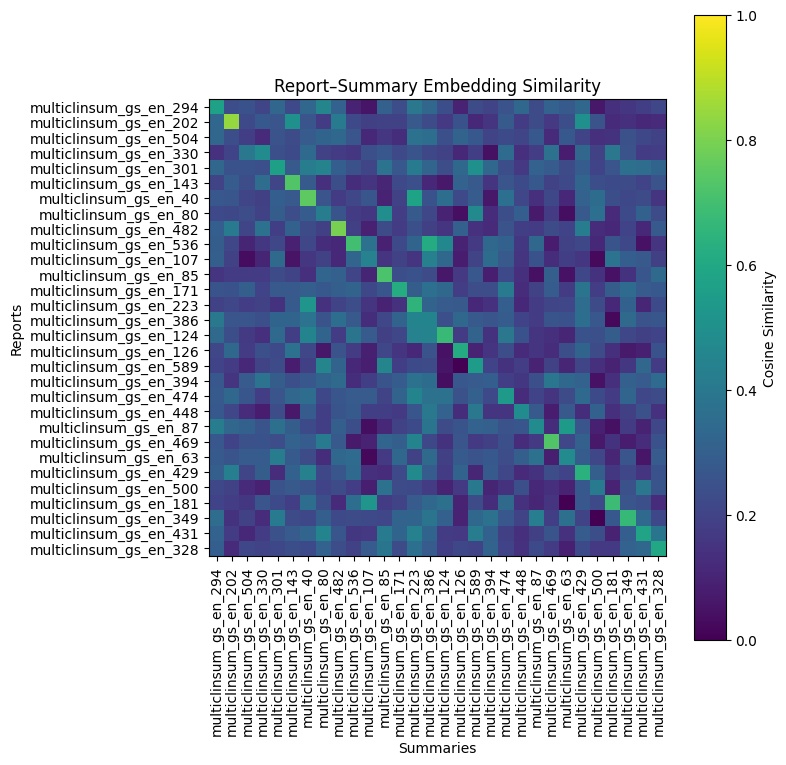

Top 10 report-summary pairs by cosine similarity
Report ID: multiclinsum_gs_en_32
Cosine similarity: 0.9924

REPORT:
this is the case of a 36-year-old woman from the oromia region’s west arsi zone, who presented with a 6-month history of snoring, dysphonia, and cough, as well as significant but unquantified weight loss, fatigue, and low-grade and intermittent fever, for which she had visited various health facilities with no noticeable improvements in her symptoms. she has had diabetes for the past 5 years and is on metformin 500 mg twice a day with poor glycemic control. the physical findings at the presentation, including the throat examination, were unremarkable. the random blood sugar level was 300 mg/dl at the time of presentation (elevated). laryngoscopy revealed an irregular tumor on the anterior one-third of the vocal cord bilaterally, involving the anterior commissure. the biopsy result revealed actinomycotic granules with abscess formation. the patient was then started on pen

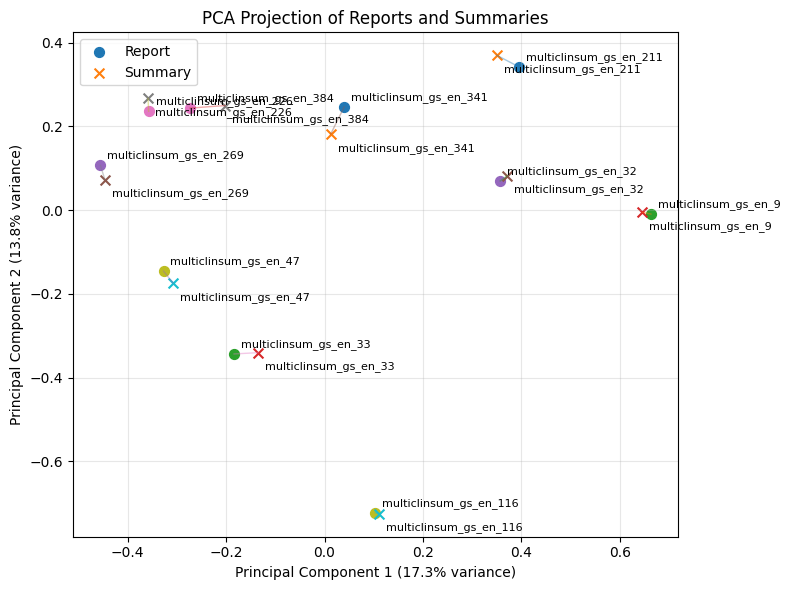

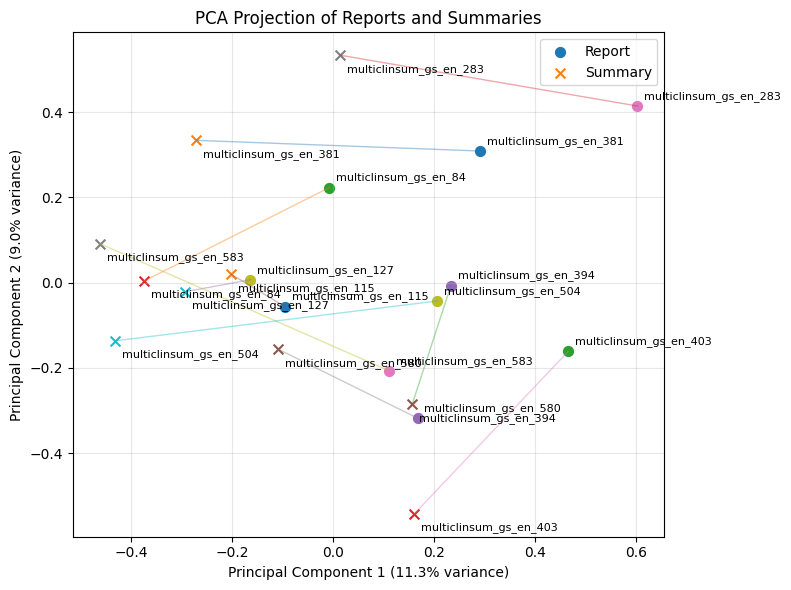

In [7]:
# ==================================================================
# 5 - EMBEDDING GENERATION baseline
# ==================================================================

print("Generating embeddings")

report_embeddings = embedding_model.encode(
    df["report_clean"].tolist(),
    show_progress_bar=True
)

summary_embeddings = embedding_model.encode(
    df["summary_clean"].tolist(),
    show_progress_bar=True
)

print("Embeddings generated.")

print("================================================")
print("EMBEDDINGS OVERVIEW")
print("================================================")

print("embeddings shape", report_embeddings.shape)  #384-dim vector from all-MiniLM-L6-v2
print(report_embeddings[0][:10])  # first 10 values of first sentence
print(summary_embeddings[0][:10])  # first 10 values of first sentence

# ==================================================================
# CHECKING EMBEDDINGS (using similarity matrix of random 30 reports)
# ==================================================================

# take 30 random embeddings
np.random.seed(222)
random_indices = np.random.choice(len(report_embeddings), size=30, replace=False)
report_emb_30 = report_embeddings[random_indices]
summary_emb_30 = summary_embeddings[random_indices]

# create a similarity matrix
similarity_matrix = cosine_similarity(report_emb_30, summary_emb_30)

# visualise heatmap of similarity matrix
plt.figure(figsize=(8, 8))
plt.imshow(similarity_matrix, cmap="viridis", vmin=0, vmax=1)
plt.xlabel("Summaries")
plt.ylabel("Reports")

plt.xticks(range(30), df["report_id"].iloc[random_indices], rotation=90)
plt.yticks(range(30), df["report_id"].iloc[random_indices])
plt.title("Report–Summary Embedding Similarity")
plt.colorbar(label="Cosine Similarity")
plt.tight_layout()
plt.show()

# ==================================================================
# CHECKING EMBEDDINGS (using PCA and visualisation)
# ==================================================================

def plotPCA(report_embeddings, summary_embeddings, report_ids):
  from sklearn.decomposition import PCA

  # Combine report and summary embeddings
  combined_embeddings = np.vstack([report_embeddings, summary_embeddings])

  # Fit PCA jointly
  pca = PCA(n_components=2)
  combined_2d = pca.fit_transform(combined_embeddings)

  # Split the PCA results back into reports and summaries
  len_reports = len(report_embeddings)
  report_2d = combined_2d[:len_reports]
  summary_2d = combined_2d[len_reports:]

  # Create paired plot
  plt.figure(figsize=(8, 6))
  for i in range(len_reports):
      # Coordinates
      report_x, report_y = report_2d[i]
      summary_x, summary_y = summary_2d[i]

      # original report_id
      report_id = report_ids[i]

      # Plot report and summary points
      plt.scatter(report_x, report_y, marker="o", s=50)
      plt.scatter(summary_x, summary_y, marker="x", s=50 )

      # Draw line connecting report and summary
      plt.plot( [report_x, summary_x], [report_y, summary_y], alpha=0.4, linewidth=1 )

      # Label with prefix R for report and S for summary
      plt.annotate( report_id, (report_x, report_y), xytext=(5, 5), textcoords="offset points", fontsize=8  )
      plt.annotate( report_id, (summary_x, summary_y), xytext=(5, -12), textcoords="offset points", fontsize=8  )

  # Labels and formatting
  plt.xlabel(f"Principal Component 1 "
      f"({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")

  plt.ylabel(f"Principal Component 2 "
      f"({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

  plt.title("PCA Projection of Reports and Summaries")
  plt.grid(True, alpha=0.3)
  plt.scatter([], [], marker="o", s=50, label="Report")
  plt.scatter([], [], marker="x", s=50, label="Summary")
  plt.legend()
  plt.tight_layout()
  plt.show()

# ==================================================================
# CHECKING ALL EMBEDDINGS (find top-10 and bottom-10 cosine similarity)
# ==================================================================

# create a similarity matrix overall all the data
similarity_all = cosine_similarity(report_embeddings, summary_embeddings)
paired_similarity = np.diag(similarity_all)

report_ids = df["report_id"].values
results = pd.DataFrame({
    "report_id": report_ids,
    "cosine_similarity": paired_similarity
})

top_10 = results.nlargest(10, "cosine_similarity")
bottom_10 = results.nsmallest(10, "cosine_similarity")

# inspect top and bottom content/text

def print_pair(res):
  for _, row in res.iterrows():
    report_id = row["report_id"]
    case = df[df["report_id"] == report_id].iloc[0]

    print("=" * 80)
    print(f"Report ID: {report_id}")
    print(f"Cosine similarity: {row['cosine_similarity']:.4f}")

    print("\nREPORT:")
    print(case["report_clean"])

    print("\nSUMMARY:")
    print(case["summary_clean"])
print("=" * 80)
print("Top 10 report-summary pairs by cosine similarity")
print_pair(top_10)
print("=" * 80)
print("Bottom 10 report-summary pairs by cosine similarity")
print_pair(bottom_10)

#### Plot PCA for top_10 cosine similarities ####

# Get report IDs from top_10
top_ids = top_10["report_id"].values

# Find POSITION of each report in the DataFrame
top_indices = np.where(df["report_id"].isin(top_ids))[0]

# Get the corresponding embeddings
top_report_embeddings = report_embeddings[top_indices]
top_summary_embeddings = summary_embeddings[top_indices]

# Make sure IDs are in the same order as the embeddings
top_ids = df["report_id"].iloc[top_indices].values

# Plot PCA for top_10 cosine similarities
plotPCA(
    top_report_embeddings,
    top_summary_embeddings,
    top_ids
)

#### Plot PCA for bottom_10 cosine similarities ####

# Get report IDs from bottom_10
bot_ids = bottom_10["report_id"].values

# Find POSITION of each report in the DataFrame
bot_indices = np.where(df["report_id"].isin(bot_ids))[0]

# Get the corresponding embeddings
bottom_report_embeddings = report_embeddings[bot_indices]
bottom_summary_embeddings = summary_embeddings[bot_indices]

# Make sure IDs are in the same order as the embeddings
bot_ids = df["report_id"].iloc[bot_indices].values
# Plot PCA for bottom_10 cosine similarities
plotPCA(
    bottom_report_embeddings,
    bottom_summary_embeddings,
    bot_ids
)



WORD COUNTS vs COSINE SIMILARITY
Empty DataFrame
Columns: [report_id, wordcount_diff]
Index: []


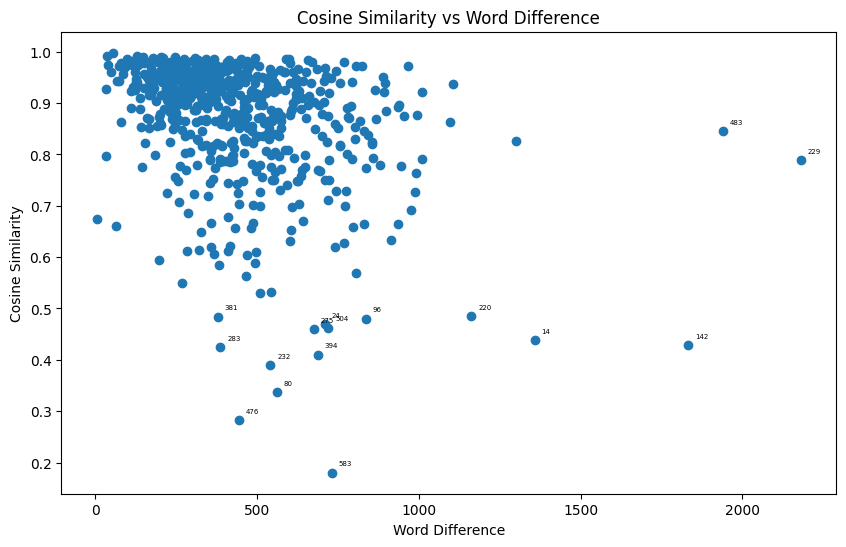

In [46]:
# ==================================================================
# 5 - EMBEDDING GENERATION biomedical
# ==================================================================

# print("Generating embeddings")

report_embeddings = embedding_biomed.encode(
    df["report_clean"].tolist(),
    show_progress_bar=True
)

summary_embeddings = embedding_biomed.encode(
    df["summary_clean"].tolist(),
    show_progress_bar=True
)

print("Embeddings generated.")

print("================================================")
print("EMBEDDINGS BIOMED OVERVIEW")
print("================================================")

print("embeddings shape", report_embeddings.shape)  #384-dim vector from all-MiniLM-L6-v2
print(report_embeddings[0][:10])  # first 10 values of first sentence
print(summary_embeddings[0][:10])  # first 10 values of first sentence

# ==================================================================
# CHECKING EMBEDDINGS (using similarity matrix of random 30 reports)
# ==================================================================

# take 30 random embeddings
np.random.seed(222)
random_indices = np.random.choice(len(report_embeddings), size=30, replace=False)
report_emb_30 = report_embeddings[random_indices]
summary_emb_30 = summary_embeddings[random_indices]

# create a similarity matrix
similarity_matrix = cosine_similarity(report_emb_30, summary_emb_30)

# visualise heatmap of similarity matrix
plt.figure(figsize=(8, 8))
plt.imshow(similarity_matrix, cmap="viridis", vmin=0, vmax=1)
plt.xlabel("Summaries")
plt.ylabel("Reports")

plt.xticks(range(30), df["report_id"].iloc[random_indices], rotation=90)
plt.yticks(range(30), df["report_id"].iloc[random_indices])
plt.title("Report–Summary Embedding Similarity")
plt.colorbar(label="Cosine Similarity")
plt.tight_layout()
plt.show()

# ==================================================================
# CHECKING EMBEDDINGS (using PCA and visualisation)
# ==================================================================

def plotPCA(report_embeddings, summary_embeddings, report_ids):
  from sklearn.decomposition import PCA

  # Combine report and summary embeddings
  combined_embeddings = np.vstack([report_embeddings, summary_embeddings])

  # Fit PCA jointly
  pca = PCA(n_components=2)
  combined_2d = pca.fit_transform(combined_embeddings)

  # Split the PCA results back into reports and summaries
  len_reports = len(report_embeddings)
  report_2d = combined_2d[:len_reports]
  summary_2d = combined_2d[len_reports:]

  # Create paired plot
  plt.figure(figsize=(8, 6))
  for i in range(len_reports):
      # Coordinates
      report_x, report_y = report_2d[i]
      summary_x, summary_y = summary_2d[i]

      # original report_id
      report_id = report_ids[i]

      # Plot report and summary points
      plt.scatter(report_x, report_y, marker="o", s=50)
      plt.scatter(summary_x, summary_y, marker="x", s=50 )

      # Draw line connecting report and summary
      plt.plot( [report_x, summary_x], [report_y, summary_y], alpha=0.4, linewidth=1 )

      # Label with prefix R for report and S for summary
      plt.annotate( report_id, (report_x, report_y), xytext=(5, 5), textcoords="offset points", fontsize=8  )
      plt.annotate( report_id, (summary_x, summary_y), xytext=(5, -12), textcoords="offset points", fontsize=8  )

  # Labels and formatting
  plt.xlabel(f"Principal Component 1 "
      f"({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")

  plt.ylabel(f"Principal Component 2 "
      f"({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

  plt.title("PCA Projection of Reports and Summaries")
  plt.grid(True, alpha=0.3)
  plt.scatter([], [], marker="o", s=50, label="Report")
  plt.scatter([], [], marker="x", s=50, label="Summary")
  plt.legend()
  plt.tight_layout()
  plt.show()

# ==================================================================
# CHECKING ALL EMBEDDINGS (find top-10 and bottom-10 cosine similarity)
# ==================================================================

# create a similarity matrix overall all the data
similarity_all = cosine_similarity(report_embeddings, summary_embeddings)
paired_similarity = np.diag(similarity_all)

report_ids = df["report_id"].values
results = pd.DataFrame({
    "report_id": report_ids,
    "cosine_similarity": paired_similarity
})

top_10 = results.nlargest(10, "cosine_similarity")
bottom_10 = results.nsmallest(10, "cosine_similarity")

# inspect top and bottom content/text

def print_pair(res):
  for _, row in res.iterrows():
    report_id = row["report_id"]
    case = df[df["report_id"] == report_id].iloc[0]

    print("=" * 80)
    print(f"Report ID: {report_id}")
    print(f"Cosine similarity: {row['cosine_similarity']:.4f}")

    print("\nREPORT:")
    print(case["report_clean"])

    print("\nSUMMARY:")
    print(case["summary_clean"])
print("=" * 80)
print("Top 10 report-summary pairs by cosine similarity")
print_pair(top_10)
print("=" * 80)
print("Bottom 10 report-summary pairs by cosine similarity")
print_pair(bottom_10)

#### Plot PCA for top_10 cosine similarities ####

# Get report IDs from top_10
top_ids = top_10["report_id"].values

# Find POSITION of each report in the DataFrame
top_indices = np.where(df["report_id"].isin(top_ids))[0]

# Get the corresponding embeddings
top_report_embeddings = report_embeddings[top_indices]
top_summary_embeddings = summary_embeddings[top_indices]

# Make sure IDs are in the same order as the embeddings
top_ids = df["report_id"].iloc[top_indices].values

# Plot PCA for top_10 cosine similarities
plotPCA(
    top_report_embeddings,
    top_summary_embeddings,
    top_ids
)

#### Plot PCA for bottom_10 cosine similarities ####

# Get report IDs from bottom_10
bot_ids = bottom_10["report_id"].values

# Find POSITION of each report in the DataFrame
bot_indices = np.where(df["report_id"].isin(bot_ids))[0]

# Get the corresponding embeddings
bottom_report_embeddings = report_embeddings[bot_indices]
bottom_summary_embeddings = summary_embeddings[bot_indices]

# Make sure IDs are in the same order as the embeddings
bot_ids = df["report_id"].iloc[bot_indices].values
# Plot PCA for bottom_10 cosine similarities
plotPCA(
    bottom_report_embeddings,
    bottom_summary_embeddings,
    bot_ids
)

print("================================================")
print("WORD COUNTS vs COSINE SIMILARITY")
print("================================================")

#### explore if cosine similarity is proportional to word count similarity ####
#### does higher cosine similarity exist between documents of a similar size? ####

#make a dataframe that has the report_ids and word counts of report_clean and summary_clean
df_wordcounts = df[["report_id", "report_clean", "summary_clean"]].copy()
df_wordcounts["report_word_count"] = df_wordcounts["report_clean"].apply(lambda x: len(x.split()))
df_wordcounts["summary_word_count"] = df_wordcounts["summary_clean"].apply(lambda x: len(x.split()))
df_wordcounts = df_wordcounts.drop(columns=["report_clean", "summary_clean"])
df_wordcounts["wordcount_diff"] = df_wordcounts["report_word_count"] - df_wordcounts["summary_word_count"]
df_wordcounts = df_wordcounts.drop(columns=["report_word_count", "summary_word_count"])
df_wordmerge = pd.merge(results, df_wordcounts, on="report_id")
df_wordmerge = df_wordmerge.sort_values(by="cosine_similarity", ascending=False)

#find any negative word count differences, in case summary not shorter
print(df_wordmerge.loc[df_wordmerge["wordcount_diff"] <= 0, ["report_id", "wordcount_diff"]])

#to simplify labels and select only a few datapoints to label
df_wordmerge["plot_report_id"] = (df_wordmerge["report_id"].str.replace("multiclinsum_gs_en_", "", regex=False))
df_label_rows = df_wordmerge[(df_wordmerge["cosine_similarity"] < 0.5) | (df_wordmerge["wordcount_diff"] > 1500)]

#plot a graph to visualise relationship
plt.figure(figsize=(10, 6))
plt.scatter(df_wordmerge["wordcount_diff"], df_wordmerge["cosine_similarity"])

#add report_id labels
for _, row in df_label_rows.iterrows():
    plt.annotate(
        row["plot_report_id"],
        (row["wordcount_diff"], row["cosine_similarity"]),
        fontsize=5,
        xytext=(5, 5),
        textcoords="offset points"
    )
plt.xlabel("Word Difference")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity vs Word Difference")
plt.show()


In [ ]:
# ==================================================================
# 6 - METRIC COMPUTATION
# ==================================================================

# ------------------------------------------------------------------
# ROUGE-L
# ------------------------------------------------------------------

rouge_scorer_model = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_scores = []

for report, summary in zip(df["report_clean"], df["summary_clean"]):
    score = rouge_scorer_model.score(report, summary)
    rouge_scores.append(score["rougeL"].fmeasure)
df["ROUGE_L"] = rouge_scores
print("ROUGE-L completed")

# ------------------------------------------------------------------
# BERTScore
# ------------------------------------------------------------------

P, R, F1 = bertscore(
    df["summary_clean"].tolist(),
    df["report_clean"].tolist(),
    lang="en",
    verbose=True
)
df["BERTScore"] = F1.numpy()
print("BERTScore completed")

# ------------------------------------------------------------------
# ENTITY RECALL + ENTITY LOSS
# ------------------------------------------------------------------

def compute_entity_recall(report_entities, summary_entities):
    report_set = set(report_entities)
    summary_set = set(summary_entities)
    if len(report_set) == 0:
        return 0
    overlap = report_set.intersection(summary_set)
    return len(overlap) / len(report_set)

entity_recalls = []

for report_entities, summary_entities in zip(df_NER["report_entities"], df_NER["summary_entities"]):
    recall = compute_entity_recall(report_entities, summary_entities)
    entity_recalls.append(recall)
df["Entity_Recall"] = entity_recalls

# NB information loss
df["NER_Loss"] = 1 - df["Entity_Recall"]
print("Entity loss completed")

# ------------------------------------------------------------------
# JENSEN-SHANNON DIVERGENCE
# ------------------------------------------------------------------

vectorizer = CountVectorizer(stop_words="english")

def compute_js_divergence(text1, text2):
    vectors = vectorizer.fit_transform( [text1, text2] )
    v1 = vectors.toarray()[0] + 1e-10
    v2 = vectors.toarray()[1] + 1e-10
    p = v1 / np.sum(v1)
    q = v2 / np.sum(v2)
    return jensenshannon(p, q)

js_scores = []

for report, summary in zip(df["report_clean"], df["summary_clean"]):
    js = compute_js_divergence(report, summary)
    js_scores.append(js)
df["JS_Divergence"] = js_scores
print("JS_Divergence completed")

## ???? also try scipy jensenshannon ?????

# ------------------------------------------------------------------
# ENTROPY LOSS
# ------------------------------------------------------------------

def compute_entropy(text):
    words = text.split()
    counts = Counter(words)
    probabilities = np.array( list(counts.values()) )
    probabilities = probabilities / probabilities.sum()
    return entropy(probabilities)   #entropy from scipy.stats

entropy_losses = []

for report, summary in zip( df["report_clean"], df["summary_clean"] ):
    report_entropy = compute_entropy(report)
    summary_entropy = compute_entropy(summary)
    if report_entropy == 0:
        entropy_losses.append(0)
    else:
        loss = 1 - ( summary_entropy / report_entropy  )
        entropy_losses.append(loss)
df["Entropy_Loss"] = entropy_losses
print("Entropy_Loss completed")

# ------------------------------------------------------------------
# EMBEDDING COSINE SIMILARITY
# ------------------------------------------------------------------

cosine_scores = []

for report_emb, summary_emb in zip(report_embeddings, summary_embeddings):
  similarity = cosine_similarity([report_emb], [summary_emb])[0][0]
  cosine_scores.append(similarity)
df["Embedding_Cosine"] = cosine_scores
print("Embedding_Cosine completed")

print(df["Embedding_Cosine"].head())


# ------------------------------------------------------------------
# Estimate mutual information between two embeddings
# ------------------------------------------------------------------

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

def compute_mutual_information(report_embeddings, summary_embeddings):
    # Convert to numpy arrays
    x = np.array(report_embeddings)
    y = np.array(summary_embeddings)

    # Reshape
    x = x.reshape(1, -1)
    y = y.reshape(-1)

    # Standardise
    scaler = StandardScaler()
    x = scaler.fit_transform(x.T).T

    # Estimate MI
    mi = mutual_info_regression( X=x.T, y=y, discrete_features=False  )

    # Mean MI across dimensions
    return np.mean(mi)


# ------------------------------------------------------------
# Mutual information estimator
# ------------------------------------------------------------

# def compute_mutual_information(report_embeddings, summary_embeddings):
#     x = np.array(report_embeddings).reshape(-1, 1)
#     y = np.array(summary_embeddings).reshape(-1, 1)
#     return mi(x, y)

mi_losses = []

for report_emb, summary_emb in zip(report_embeddings, summary_embeddings):
  mi_score = compute_mutual_information(report_emb, summary_emb)
  # Convert MI into loss score, higher MI = lower information loss
  info_loss = np.exp(-mi_score)
  mi_losses.append(info_loss)
df["MI_Information_Loss"] = mi_losses
print("MI_Information_Loss completed")

# # ------------------------------------------------------------------
# # NMI LOSS
# # ------------------------------------------------------------------

# print("Normalise Mutual Information")

# nmi_scores = []
# info_loss_percentages = []

# for report, summary in zip( df["report_clean"], df["summary_clean"] ):
#     nmi = normalized_mutual_info_score(report, summary)
#     nmi_scores.append(nmi)
#     # Calculate relative information loss
#     info_loss_perc = (1 - nmi) * 100
#     info_loss_percentages.append(info_loss_perc)
# df["NMI"] = nmi_scores
# df["IL%"] = info_loss_percentages


# ==================================================================
# 6. FINAL INFORMATION LOSS SCORE
# ==================================================================

print("Computing final Information Loss Score\n")

"""
Weighted composite score, Adjust weights experimentally later
"""

alpha = 0.35   # NER loss
beta = 0.25    # JS divergence
gamma = 0.20   # entropy loss
delta = 0.20   # embedding semantic loss

df["Information_Loss_Score"] = (
    alpha * df["NER_Loss"]
    + beta * df["MI_Information_Loss"]
    + gamma * (1 - df["BERTScore"])
)

# ctrl /
df["Clinical_Information_Loss"] = (
    alpha * df["MI_Information_Loss"]
    + beta * (1 - df["BERTScore"])
    + gamma * df["NER_Loss"]
)
print("Final Information Loss Score completed")


In [ ]:

# ==================================================================
# 7 - ANALYSIS
# ==================================================================

#convert ROUGE, BERT and cosine into differences instead of similarities
df['ROUGEdiff'] = 1- df['ROUGE_L']
df['BERTdiff'] = 1- df['BERTScore']
df['Cosinediff'] = 1- df['Embedding_Cosine']
print("SUMMARY STATISTICS")
metrics = [
    "ROUGEdiff",
    "BERTdiff",
    "Cosinediff",
    "NER_Loss",
    "JS_Divergence",
    "Entropy_Loss",
    "MI_Information_Loss",
    "Information_Loss_Score"
]
summary_stats = df[metrics].describe()
print(summary_stats)
summary_stats.to_csv('summary_statistics.csv')

# DETECT HIGH-LOSS SUMMARIES

print("THRESHOLD ANALYSIS")
threshold = df["Information_Loss_Score"].quantile(0.90)
print("High-loss threshold:", threshold)
df["Poor_Summary"] = (df["Information_Loss_Score"] > threshold)
print("Poor summaries detected:", df["Poor_Summary"].sum())


# ==================================================================
# 8 - VISUALISATIONS
# ==================================================================


# METRIC CORRELATION HEATMAP
print("CORRELATION MATRIX")
correlation_matrix = df[metrics].corr()
print(correlation_matrix)

# PLOT
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.colorbar()
plt.title("Metric Correlation Matrix")
plt.tight_layout()
plt.show()

# alternative in seaborn
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,          # show values in cells
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",
    vmin=0.2,            # lower limit
    vmax=0.8,            # upper limit
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Metric Correlation Matrix")
plt.tight_layout()
plt.show()


# BERTScore vs ROUGE-L scores AND Entity Recall
# These are how similar the full reports and summaries are

plt.figure(figsize=(8, 5))
poor = df[df["Poor_Summary"] == True]
plt.scatter(df["BERTScore"], df["ROUGE_L"], color="b", label="ROUGE-L Score")
plt.scatter(df["BERTScore"], df["Entity_Recall"], color="r", label="Entity Recall")
# Highlight poor summaries with black crosses
plt.scatter(poor["BERTScore"], poor["ROUGE_L"], color="yellow", marker="x", s=100, label="Poor Summary (ROUGE-L)")
plt.scatter(poor["BERTScore"], poor["Entity_Recall"], color="black", marker="x", s=100, label="Poor Summary (Entity Recall)")
plt.xlabel("BERTScore")
plt.ylabel("Score")
plt.title("Lexical overlap (ROUGE-L) vs Semantic Similarity (BERTscore)")
plt.legend()
plt.show()


# BOXPLOT

plt.figure(figsize=(6, 5))
plt.boxplot([
    df[ df["Poor_Summary"] == False ]["Information_Loss_Score"],
    df[ df["Poor_Summary"] == True ]["Information_Loss_Score"]
])
plt.xticks([1, 2], ["Good", "Poor"])
plt.ylabel("Information Loss Score")
plt.title("Good vs Poor Summaries")
plt.show()


# HISTOGRAM of BOTH my Information Loss Score and MI

plt.figure(figsize=(8, 5))
plt.hist(df["Information_Loss_Score"], bins=30, color="r", label="Information Loss", alpha=0.5 )
plt.hist(df["MI_Information_Loss"], bins=30, color="b", label="MI Loss", alpha=0.5 )
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("MI vs Proposed Information Loss Score")
plt.legend()
plt.show()


# HISTOGRAM of two different information loss scores

plt.figure(figsize=(8, 5))
plt.hist(df["MI_Information_Loss"], bins=30, color="b", label="Without MI", alpha=0.5 )
plt.hist(df["Clinical_Information_Loss"], bins=30, color="r", label="With MI", alpha=0.5 )
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Comparison of Two Possible Information Loss Scores")
plt.legend()
plt.show()


# ==================================================================
# 9 - SAVE RESULTS
# ==================================================================

OUTPUT_FILE = "multiclinsum_information_loss_results.csv"
df.to_csv(OUTPUT_FILE, index=False)
print("RESULTS SAVED as", OUTPUT_FILE)
